# Pairs trading on the day lake — V. Avellaneda-Lee, the half notebook 12 skipped

## `pairs_trading_18_avellaneda_lee_day_lake.ipynb`

Notebook 12 ran the cross-section two ways: plain reversal against the day's own history, and a
PCA factor model borrowed from Avellaneda & Lee (2010). It never ran the paper's *own*
configuration — sector-ETF residuals instead of PCA eigenportfolios, the "trading time" volume
correction of section 6, and the bang-bang open/close rule of eq. 16 instead of a continuously
rebalanced target. It also never hedged the PCA book against anything, so that branch carried
uncompensated market beta throughout. This notebook fills in that half.

The question is narrow: does the paper's own machinery carry more gross edge per unit of turnover
than notebook 12's best variant, and does any of it survive 2016–2025? Notebook 12 already
established (its numbers are re-printed here from this notebook's own baseline run, not quoted)
that turnover was the binding constraint on the PCA/reversal book and that its gross edge died
after 2015. Three things are new here:

1. **Sector ETFs instead of PCA.** Each name is assigned, monthly and point-in-time, to the
   candidate sector ETF whose trailing-year returns explain it best (no sector classification
   exists in this repository, so this replaces the paper's hand-assigned GICS mapping).
2. **Trading time.** Section 6's volume-modified returns, folded into the residual regression
   exactly where the paper puts them, compared against calendar-time on the same names and dates.
3. **The bang-bang rule.** Eq. 16's full-size-on-open, hold-to-close-signal trading rule, run as
   its own book (not just as a diagnostic s-score), alongside a continuous version for comparison
   with notebook 12's damped-target design.

Six books are built side by side, all sharing the same universe, cost machinery and evaluation
window: two calendar/trading-time bang-bang books, two calendar/trading-time continuous books, a
hedged PCA bang-bang book, and notebook 12's own raw-reversal baseline. The short version of the
answer the numbers give, on a per-turnover basis pooling stock and ETF legs: no — no configuration
tested here earns more gross P&L per dollar traded than notebook 12's plain reversal signal (break-even
5.703 bps, against a best of 4.423 bps for the paper's own machinery); counted on stock legs only, the
only turnover notebook 12's book has, the trading-time books do clear it (6.857 and 5.837 bps; §4.3). Net of
*measured* costs, though, the answer flips: the corrected trading-time bang-bang book is the single
best-performing run in the notebook. Getting "trading time" right took correcting two independent
bugs, not one — a scoring bug in this notebook's own s-score call, and, on top of that, which
regression eq. 20's volume weighting actually describes (§3, §6) — and the usual
pre-2016-works/post-2016-doesn't pattern seen elsewhere in this repository shows up, to varying
degrees, in five of the six runs on a two-decade split, though five-year blocks (§5) complicate even
that reading (§7).

## 0.1 Setup

In [1]:
from pathlib import Path
import os, re, sys, time, pickle, warnings

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pairs
from pairs import (load_daily_bars, liquidity_screen, CostSpec, measure_ticker_window_costs)
from pairs.strategies.avellaneda_lee import (
    assign_sector_etf, trading_time_factor, etf_residuals, ou_fit, s_score,
    bang_bang_update, positions_from_state,
)

LAKE        = Path(os.environ.get("DAY_LAKE", Path.home() / "local/parquet_lake/day_adj"))
MARKET_ROOT = LAKE / "all_adjusted"
MINUTE_ROOT = Path(os.environ.get("MINUTE_LAKE",
                                  Path.home() / "local/parquet_lake/minute_adj")) / "all_adjusted"
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)

START, END        = "2004-01-01", "2025-08-13"
TRADE_START       = "2006-01-01"
DECADE_SPLIT      = pd.Timestamp("2016-01-01")
MIN_PRICE, MIN_DV, MIN_VOL, MAX_ABS_RET = 5.0, 20e6, 0.15, 1.0
UNIV_N, FORM_DAYS, REG_DAYS, N_FACTORS = 500, 252, 60, 15
CAP          = 1_000_000.0
LAMBDA_LEGS  = 200                    # paper's "2+2" leverage, ~100 long + ~100 short
NOTIONAL     = CAP / LAMBDA_LEGS      # fixed $ per open bang-bang stock leg
REBUILD_GAP  = 25                     # days between monthly universe/assignment/PCA rebuilds
COST_BPS     = 5.0                    # flat-cost comparison point, as nb12

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
Z = lambda a: (a - np.nanmean(a)) / (np.nanstd(a) + 1e-12)
sharpe = lambda x: x.mean() / x.std(ddof=0) * np.sqrt(252) if x.std(ddof=0) > 0 else np.nan
print("pairs", pairs.__version__)

pairs 0.1.0


## 1. Data

Same cached day-lake frame notebook 12 uses (`cache/day_market_bars.parquet`), with the same
total-return construction, the same ±100%/day winsorizing, and the same exchange-test-symbol drop.

In [2]:
f_bars = CACHE / "day_market_bars.parquet"
if not f_bars.exists():
    load_daily_bars(None, START, END, MARKET_ROOT, with_dividends=True).to_parquet(f_bars)
bars = pd.read_parquet(f_bars)
print("bars columns:", list(bars.columns), " — volume present:", "volume" in bars.columns)

px  = bars["close"].unstack("ticker")
div = bars["dividend"].unstack("ticker").reindex_like(px).fillna(0.0)
ret = ((px + div) / px.shift(1) - 1.0).clip(-1.0, 1.0)
TESTS = sorted(t for t in px.columns if re.fullmatch(r"Z[A-Z]ZZT", str(t)))
ret = ret.drop(columns=TESTS, errors="ignore")
sessions = ret.index
print(f"{ret.shape[1]:,} tickers x {ret.shape[0]:,} sessions, {sessions[0].date()} -> {sessions[-1].date()}")
print(f"exchange test symbols dropped: {TESTS}")

# volume: cached bars already carry it (checked above), so no separate al_volume.parquet is needed
vol = bars["volume"].unstack("ticker")
print(f"volume panel: {vol.shape[1]:,} tickers x {vol.shape[0]:,} sessions, "
      f"{100*vol.notna().to_numpy().mean():.1f}% non-null cells")

bars columns: ['close', 'raw_close', 'volume', 'dollar_volume', 'id', 'dividend']  — volume present: True


33,303 tickers x 5,438 sessions, 2004-01-02 -> 2025-08-13
exchange test symbols dropped: ['ZAZZT', 'ZBZZT', 'ZCZZT', 'ZDZZT', 'ZEZZT', 'ZFZZT', 'ZJZZT', 'ZOZZT', 'ZRZZT', 'ZUZZT', 'ZVZZT', 'ZWZZT', 'ZXZZT']


volume panel: 33,316 tickers x 5,438 sessions, 24.2% non-null cells


### 1.1 Candidate sector ETFs

Continuity is checked data-driven rather than assumed: for each candidate, the largest gap (in
trading sessions) between consecutive non-null return observations, and the last date it is seen.
A candidate with a gap bigger than 5 sessions, or whose data stops well before the end of the
sample, is dropped — this is expected to catch `HHH` (ticker reuse, scattered coverage), `UTH`
(ends 2011-12) and `RKH` (ends 2014-12), all flagged in advance as known offenders, plus anything
else that turns out to have the same problem.

In [3]:
CANDIDATES = ["XLB", "XLE", "XLF", "XLI", "XLK", "XLP", "XLU", "XLV", "XLY",
              "IYR", "SMH", "OIH", "RTH", "IBB", "IYT", "KRE", "HHH", "UTH", "RKH"]
rows = []
for t in CANDIDATES:
    if t not in ret.columns:
        rows.append({"etf": t, "first": None, "last": None, "max_gap_sessions": None, "n_obs": 0})
        continue
    s = ret[t].dropna()
    if len(s) < 2:
        rows.append({"etf": t, "first": s.index.min(), "last": s.index.max(),
                     "max_gap_sessions": None, "n_obs": len(s)})
        continue
    pos = sessions.get_indexer(s.index)
    gaps = np.diff(pos)
    rows.append({"etf": t, "first": s.index.min().date(), "last": s.index.max().date(),
                 "max_gap_sessions": int(gaps.max()), "n_obs": len(s)})
etf_coverage = pd.DataFrame(rows).set_index("etf")
display(etf_coverage)

BAD = etf_coverage.index[
    etf_coverage["max_gap_sessions"].isna()
    | (etf_coverage["max_gap_sessions"] > 5)
    | (pd.to_datetime(etf_coverage["last"]) < pd.Timestamp("2025-01-01"))
].tolist()
ETF_LIST = [t for t in CANDIDATES if t not in BAD]
print(f"dropped for discontinuity: {BAD}")
print(f"clean sector-ETF list ({len(ETF_LIST)}): {ETF_LIST}")

assert "SPY" in ret.columns
spy_gap = np.diff(sessions.get_indexer(ret["SPY"].dropna().index)).max()
print(f"SPY (used only for the PCA book's hedge, not as a sector candidate): "
      f"max gap {spy_gap} sessions, last date {ret['SPY'].dropna().index.max().date()}")

etf_ret = ret[ETF_LIST]

,first,last,max_gap_sessions,n_obs
etf,,,,
XLB,2004-01-05,2025-08-13,1,5437
XLE,2004-01-05,2025-08-13,1,5437
XLF,2004-01-05,2025-08-13,1,5437
XLI,2004-01-05,2025-08-13,1,5437
XLK,2004-01-05,2025-08-13,1,5437
XLP,2004-01-05,2025-08-13,1,5437
XLU,2004-01-05,2025-08-13,1,5437
XLV,2004-01-05,2025-08-13,1,5437
XLY,2004-01-05,2025-08-13,1,5437


dropped for discontinuity: ['HHH', 'UTH', 'RKH']
clean sector-ETF list (16): ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY', 'IYR', 'SMH', 'OIH', 'RTH', 'IBB', 'IYT', 'KRE']
SPY (used only for the PCA book's hedge, not as a sector candidate): max gap 1 sessions, last date 2025-08-13


## 2. Sector assignment

Each name is assigned to the candidate ETF whose trailing-252-session returns explain it best
(`assign_sector_etf`, §Appendix substitute — see the module docstring for why this is data-driven
rather than GICS-based). Rebuilt monthly, alongside the point-in-time universe and the PCA
eigenportfolios notebook 12 already uses, all on the same 25-day cadence.

In [4]:
def universe_at(end, n=UNIV_N):
    start = end - pd.DateOffset(days=int(FORM_DAYS * 1.6))
    lvl = bars.index.get_level_values("datetime")
    w = bars[(lvl > start) & (lvl <= end)]
    st = liquidity_screen(w, min_price=MIN_PRICE, min_dollar_volume=MIN_DV, min_ann_vol=MIN_VOL,
                          max_abs_return=MAX_ABS_RET, exclude=TESTS, top_n=n)
    names = list(st[st["eligible"]].index)
    return [t for t in names if t not in ETF_LIST and t != "SPY"]

def eigenportfolios(R, k=N_FACTORS):
    # verbatim from notebook 12 (build_cross_sectional_notebook.py section 2)
    sd = R.std(axis=0); ok = sd > 1e-12
    R, sd = R.loc[:, ok], sd[ok]
    C = np.nan_to_num(np.corrcoef(R.to_numpy(), rowvar=False), nan=0.0)
    vals, vecs = np.linalg.eigh(C)
    idx = np.argsort(vals)[::-1][:k]
    Q = vecs[:, idx] / sd.to_numpy()[:, None]
    Q = Q / np.abs(Q).sum(axis=0, keepdims=True)
    return pd.DataFrame(Q, index=R.columns, columns=[f"f{i}" for i in range(len(idx))]), vals[idx] / vals.sum()

def s_score_al(resid):
    # verbatim from notebook 12 (build_cross_sectional_notebook.py section 3) -- kept unchanged so
    # this notebook's IC test reproduces notebook 12's own printed number for this construction.
    X = np.cumsum(resid, axis=0)
    x0, x1 = X[:-1], X[1:]
    mx0, mx1 = x0.mean(0), x1.mean(0)
    cov = ((x0 - mx0) * (x1 - mx1)).sum(0); var = ((x0 - mx0) ** 2).sum(0)
    b = np.divide(cov, var, out=np.zeros_like(cov), where=var > 1e-18)
    a = mx1 - b * mx0
    zeta = x1 - (a + b * x0)
    var_z = (zeta ** 2).sum(0) / max(len(x0) - 2, 1)
    with np.errstate(divide="ignore", invalid="ignore"):
        kappa = -np.log(np.clip(b, 1e-9, 0.999999)) * 252.0
        m = a / (1.0 - b); sigma_eq = np.sqrt(var_z / (1.0 - b ** 2))
        s = (X[-1] - m) / sigma_eq
    bad = (b <= 0) | (b >= 1) | ~np.isfinite(s) | (sigma_eq <= 1e-12)
    return np.where(bad, np.nan, s), np.where(bad, np.nan, kappa)

In [5]:
t0 = time.time()
ASSIGN_HISTORY = []
d, i = pd.Timestamp(TRADE_START), sessions.searchsorted(pd.Timestamp(TRADE_START))
while d <= pd.Timestamp(END) and i < len(sessions):
    d = sessions[i]
    univ = universe_at(d)
    hist = ret.iloc[i - FORM_DAYS:i].reindex(columns=univ).dropna(axis=1)
    if hist.shape[1] >= 50:
        etf_hist = etf_ret.iloc[i - FORM_DAYS:i]
        a_df = assign_sector_etf(hist, etf_hist, min_obs=200)
        ASSIGN_HISTORY.append((d, a_df))
    # jump ~REBUILD_GAP trading sessions ahead
    i += REBUILD_GAP
print(f"{len(ASSIGN_HISTORY)} monthly assignment snapshots built in {time.time()-t0:.0f}s")

sample_i = len(ASSIGN_HISTORY) // 2
sample_date, sample_assign = ASSIGN_HISTORY[sample_i]
counts = sample_assign["etf"].value_counts()
print(f"sample date: {sample_date.date()}, {sample_assign['etf'].notna().sum()} names assigned")
display(counts.to_frame("n names"))
print(f"median R^2 on {sample_date.date()}: {sample_assign['r2'].median():.3f}")
print(f"share of names with R^2 < 0.10 on {sample_date.date()}: {(sample_assign['r2'] < 0.10).mean():.1%}")

persist = []
for (d0, a0), (d1, a1) in zip(ASSIGN_HISTORY[:-1], ASSIGN_HISTORY[1:]):
    common = a0.index.intersection(a1.index)
    common = common[a0.loc[common, "etf"].notna() & a1.loc[common, "etf"].notna()]
    if len(common):
        persist.append((a0.loc[common, "etf"] == a1.loc[common, "etf"]).mean())
persist = np.array(persist)
print(f"month-to-month persistence: mean {persist.mean():.1%} of names keep their ETF "
      f"(over {len(persist)} consecutive rebuild pairs, min {persist.min():.1%}, max {persist.max():.1%})")

198 monthly assignment snapshots built in 335s
sample date: 2015-11-02, 484 names assigned


,n names
etf,
XLI,70
XLY,56
XLE,50
XLK,41
XLF,41
XLB,36
XLV,36
XLP,24
OIH,23


median R^2 on 2015-11-02: 0.492
share of names with R^2 < 0.10 on 2015-11-02: 1.9%
month-to-month persistence: mean 90.4% of names keep their ETF (over 197 consecutive rebuild pairs, min 73.1%, max 96.2%)


## 3. Signals and information coefficients

Before any portfolio: on notebook 12's probe days (every 5th trading session from `TRADE_START`),
four candidate signals are cross-sectionally correlated against the next day's and next five days'
**ETF-hedged forward return**, y(t+1) − β̂·x(t+1) with no in-sample intercept subtracted (see the
callout in the code cell below for why the intercept has to go) — the same dependent variable for
every signal, so the comparison is apples to apples. The ETF-model s-score is built two ways
(calendar, trading time, the latter under the paper-faithful unscaled-intercept reading — see §3's
code and the module docstring); the PCA-model s-score reuses notebook 12's
`eigenportfolios`/`s_score_al` construction, on this notebook's own rebuild schedule (every session
more than 25 days after the last rebuild, not notebook 12's probe-day schedule) and against this
notebook's own forward-return target, not notebook 12's — so its printed IC here is the same
*construction* on different inputs, not a number expected to reproduce notebook 12's (§7 quantifies
the gap and where it actually comes from).

In [6]:
PROBE_DAYS = set(sessions[(sessions >= TRADE_START) & (sessions <= END)][::5])
print(f"{len(PROBE_DAYS)} probe days")

TT_FULL = trading_time_factor(vol, window=10, clip=(0.1, 10.0))
print(f"trading-time factor: {100*TT_FULL.notna().to_numpy().mean():.1f}% non-null cells, "
      f"median {np.nanmedian(TT_FULL.to_numpy()):.2f}, "
      f"clipped at {(TT_FULL.to_numpy() <= 0.1).sum() + (TT_FULL.to_numpy() >= 10.0).sum():,} cells")

987 probe days


trading-time factor: 21.9% non-null cells, median 1.18, clipped at 1,045,676 cells


In [7]:
def assignment_asof(d):
    # last rebuilt assignment on or before d
    idx = np.searchsorted([x[0] for x in ASSIGN_HISTORY], d, side="right") - 1
    return ASSIGN_HISTORY[max(idx, 0)][1]

def pca_asof_cache():
    cache = {}
    def get(d, univ):
        key = d
        if key not in cache:
            i = sessions.get_loc(d)
            hist = ret.iloc[i - FORM_DAYS:i].reindex(columns=univ).dropna(axis=1)
            Q, _ = eigenportfolios(hist)
            cache[key] = Q
        return cache[key]
    return get

ic_rows = []
kappa_pass = {"calendar": [], "trading_time": []}
kappa_b    = {"calendar": [], "trading_time": []}   # raw AR(1) b_hat, every day (finding 6)
t0 = time.time()
last_rebuild, univ, assign_df, Q = None, [], None, None

for i, d in enumerate(sessions):
    if d < pd.Timestamp(TRADE_START) or d > pd.Timestamp(END):
        continue
    if i < FORM_DAYS + REG_DAYS + 2 or i + 6 >= len(sessions):
        continue
    if last_rebuild is None or (d - last_rebuild).days > REBUILD_GAP:
        univ = universe_at(d)
        hist = ret.iloc[i - FORM_DAYS:i].reindex(columns=univ).dropna(axis=1)
        if hist.shape[1] < 50:
            continue
        assign_df = assign_sector_etf(hist, etf_ret.iloc[i - FORM_DAYS:i], min_obs=200)
        Q, _ = eigenportfolios(hist)
        univ = list(Q.index)
        last_rebuild = d

    win = ret.iloc[i - REG_DAYS:i].reindex(columns=univ).dropna(axis=1)
    if win.shape[1] < 30:
        continue
    etf_of = assign_df["etf"].reindex(win.columns)
    ok_names = etf_of.notna() & etf_of.isin(ETF_LIST)
    cols = win.columns[ok_names.to_numpy()]
    if len(cols) < 30:
        continue
    win = win[cols]
    etf_of = etf_of[cols]
    etf_win = etf_ret.loc[win.index, etf_of.tolist()]
    etf_win.columns = cols

    fit_cal = etf_residuals(win.to_numpy(), etf_win.to_numpy(), weights=None)
    ou_cal = ou_fit(fit_cal["resid"])
    # Trading time, paper-faithful reading (finding 3): scale BOTH sides by the trading-time
    # factor and fit an ordinary, UNSCALED intercept -- f*y = alpha + beta*(f*x) + eps -- rather
    # than scaling the intercept column too (etf_residuals' own `weights=` argument, which fits a
    # weighted least squares with the intercept column itself equal to f; see that function's
    # docstring). The unscaled-intercept reading keeps X_60 = sum(eps) = 0 by the same OLS
    # identity as the calendar fit, matching the paper's own remark that modified returns "are
    # equal to the classical returns if the daily trading volume is typical" -- a mild reweighting
    # of the same intercept regression, not a different estimator with a different X_60 geometry.
    ttf_win = TT_FULL.loc[win.index, cols]
    f_tt = ttf_win.to_numpy()
    fit_tt = etf_residuals(f_tt * win.to_numpy(), f_tt * etf_win.to_numpy(), weights=None)
    ou_tt = ou_fit(fit_tt["resid"])
    kappa_pass["calendar"].append(ou_cal["model_ok"])
    kappa_pass["trading_time"].append(ou_tt["model_ok"])
    kappa_b["calendar"].append(ou_cal["b"])
    kappa_b["trading_time"].append(ou_tt["b"])

    if d not in PROBE_DAYS:
        continue

    s_cal = pd.Series(s_score(ou_cal, center=True), index=cols)
    s_tt = pd.Series(s_score(ou_tt, center=True), index=cols)

    Qw = Q.reindex(cols).to_numpy()
    R = win.to_numpy()
    F = R @ Qw
    Fm = np.column_stack([np.ones(len(F)), F])
    beta_pca, *_ = np.linalg.lstsq(Fm, R, rcond=None)
    resid_pca = R - Fm @ beta_pca
    s_al_pca, kappa_pca = s_score_al(resid_pca)

    raw_rev5 = -Z(win.to_numpy()[-5:].sum(0))

    fwd_stock = ret.iloc[i + 1:i + 6][cols]
    fwd_etf = etf_ret.loc[fwd_stock.index, etf_of.tolist()]
    fwd_etf.columns = cols
    # No in-sample intercept: the target is the ETF-hedged forward return actually earned by a
    # beta-hedged $1 position, y(t+1) - beta_hat*x(t+1), not y(t+1) - (alpha_hat + beta_hat*x(t+1)).
    # alpha_hat is a per-name 60-day in-sample MEAN return with material cross-sectional dispersion
    # of its own (see the caveat in section 3 below); subtracting it from the forward return makes
    # any signal built from the same 60-day window co-move with the target through alpha_hat alone,
    # with zero true predictive content -- a target-definition artifact, not a forecast (finding 2).
    fwd_resid = fwd_stock.to_numpy() - fit_cal["beta"] * fwd_etf.to_numpy()
    fwd1 = fwd_resid[0]
    fwd5 = fwd_resid.sum(0)

    ic_rows.append(pd.DataFrame({
        "ETF s-score (calendar)": -s_cal.to_numpy(), "ETF s-score (trading time)": -s_tt.to_numpy(),
        "PCA s-score (nb12)": -s_al_pca, "raw reversal 5d": raw_rev5,
        "b_cal": ou_cal["b"], "b_tt": ou_tt["b"],   # raw AR(1) b_hat on probe days (finding 6)
        "model_ok_cal": ou_cal["model_ok"],  # the actual raw kappa gate (finite b, 0<b<1, kappa>252/30)
        "fwd1": fwd1, "fwd5": fwd5,
    }, index=cols).assign(date=d))

ic_panel = pd.concat(ic_rows)
print(f"IC panel built in {time.time()-t0:.0f}s: {len(ic_panel):,} name-days over "
      f"{ic_panel['date'].nunique()} probe days")

kp_cal = np.concatenate(kappa_pass["calendar"])
kp_tt = np.concatenate(kappa_pass["trading_time"])
print(f"kappa pass rate, ETF model calendar: {kp_cal.mean():.1%} of {len(kp_cal):,} name-days")
print(f"kappa pass rate, ETF model trading time: {kp_tt.mean():.1%} of {len(kp_tt):,} name-days")

IC panel built in 527s: 481,120 name-days over 986 probe days
kappa pass rate, ETF model calendar: 99.1% of 2,404,627 name-days
kappa pass rate, ETF model trading time: 99.3% of 2,404,627 name-days


In [8]:
# The 30-day mean-reversion gate (kappa > 252/30, i.e. b < 0.9672) is fit by OLS on 59 consecutive
# pairs of a 60-observation window; Kendall's small-sample AR(1) result gives E[b_hat] roughly
# b - (1+3b)/59, so a true b near the 0.9672 cutoff is systematically estimated well below it and
# the raw pass rate above overstates how many names are genuinely fast mean-reverting (finding 6).
# Bias-correct b_hat and recompute the gate, over every fitted name-day (not just probe days).
kb_cal = np.concatenate(kappa_b["calendar"])
kb_tt = np.concatenate(kappa_b["trading_time"])
W_AR1 = REG_DAYS - 1   # number of consecutive AR(1) pairs the b_hat above was fit on

def bias_corrected_gate(b, n=W_AR1):
    b_c = b + (1.0 + 3.0 * b) / n
    with np.errstate(divide="ignore", invalid="ignore"):
        kappa_c = -np.log(np.clip(b_c, 1e-9, 0.999999)) * 252.0
    return np.isfinite(b_c) & (b_c > 0) & (b_c < 1) & np.isfinite(kappa_c) & (kappa_c > 252.0 / 30.0)

ok_corr_cal, ok_corr_tt = bias_corrected_gate(kb_cal), bias_corrected_gate(kb_tt)
print(f"median raw AR(1) b_hat: calendar {np.nanmedian(kb_cal):.3f}, trading time {np.nanmedian(kb_tt):.3f}")
print(f"bias-corrected kappa pass rate (Kendall small-sample correction, {W_AR1} pairs): "
      f"calendar {ok_corr_cal.mean():.1%}, trading time {ok_corr_tt.mean():.1%} "
      f"(raw gate: {kp_cal.mean():.1%} / {kp_tt.mean():.1%})")

# Null check: does an iid (non-mean-reverting) residual pass the raw gate about as often as real
# data does, confirming the pass rate is mostly the small-sample bias and not real fast reversion?
rng_null = np.random.default_rng(0)
null_resid = rng_null.standard_normal((REG_DAYS, 20_000)) * np.nanstd(fit_cal["resid"])
ou_null = ou_fit(null_resid)
print(f"iid-null (zero true mean reversion) raw gate pass rate: {np.nanmean(ou_null['model_ok']):.1%} "
      f"of {null_resid.shape[1]:,} simulated name-windows")

median raw AR(1) b_hat: calendar 0.877, trading time 0.864
bias-corrected kappa pass rate (Kendall small-sample correction, 59 pairs): calendar 66.2%, trading time 72.1% (raw gate: 99.1% / 99.3%)
iid-null (zero true mean reversion) raw gate pass rate: 78.2% of 20,000 simulated name-windows


In [9]:
SIGNAL_COLS = ["raw reversal 5d", "ETF s-score (calendar)", "ETF s-score (trading time)", "PCA s-score (nb12)"]

def _pairwise_ic(g, c, fwd):
    mask = g[c].notna() & g[fwd].notna()
    if mask.sum() > 30:
        return np.corrcoef(g.loc[mask, c], g.loc[mask, fwd])[0, 1]
    return np.nan

def ic_table(fwd):
    out = []
    for c in SIGNAL_COLS:
        per_day = ic_panel.groupby("date").apply(lambda g: _pairwise_ic(g, c, fwd)).dropna()
        a = per_day.to_numpy()
        out.append({"signal": c, "mean IC": a.mean(), "t": a.mean() / a.std(ddof=1) * np.sqrt(len(a)),
                    "share of days > 0": (a > 0).mean(), "n days": len(a)})
    return pd.DataFrame(out).set_index("signal")

ic1, ic5 = ic_table("fwd1"), ic_table("fwd5")
display(pd.concat({"next day": ic1, "next 5 days": ic5}, axis=1).round(4))

next day                                   \
                            mean IC       t share of days > 0 n days   
signal                                                                 
raw reversal 5d             -0.0016 -0.3413            0.4888    986   
ETF s-score (calendar)       0.0061  1.9345            0.5254    986   
ETF s-score (trading time)   0.0089  2.8439            0.5355    986   
PCA s-score (nb12)          -0.0004 -0.2143            0.5010    986   

                           next 5 days                                   
                               mean IC       t share of days > 0 n days  
signal                                                                   
raw reversal 5d                 0.0048  1.1222            0.5152    986  
ETF s-score (calendar)          0.0065  2.1114            0.5193    986  
ETF s-score (trading time)      0.0099  3.2420            0.5375    986  
PCA s-score (nb12)              0.0045  2.1122            0.5274    986

## 4. The book

Six runs share the same daily construction pass: **(a)** ETF, calendar, bang-bang; **(b)** ETF,
trading time, bang-bang; **(c)** ETF, calendar, continuous (weights ∝ −s̄, dollar-neutral, scaled
to \$1M gross, blend 0.25 as notebook 12); **(d)** ETF, trading time, continuous; **(e)** PCA,
calendar, bang-bang, hedged with SPY only, sized to each name's trailing-60d SPY beta; **(f)**
notebook 12's own raw-reversal-5d/blend-0.25 baseline, loaded from its own cache and evaluated with
this notebook's cost machinery. A name that drops out of the point-in-time universe or loses a
valid sector assignment is closed the same day it drops (full turnover charged that session) for
the bang-bang runs, and decays under the same blend factor as every other name for the continuous
runs, carrying its last-known beta/ETF forward until it is fully unwound — same behavior notebook
12's own `run()` already has for a name leaving its monthly-rebuilt universe.

In [10]:
positions = {k: {} for k in "abcde"}
n_open    = {k: {} for k in "abcde"}
FWD       = {}

state       = {k: pd.Series(dtype=float) for k in "abe"}
entry_day   = {k: {} for k in "abe"}
holding     = {k: [] for k in "abe"}
forced_close = {k: 0 for k in "abe"}
prev_w      = {k: pd.Series(dtype=float) for k in "cd"}
last_beta   = {k: {} for k in "cd"}
last_etf_of = {}

last_rebuild, univ, assign_df, Q = None, [], None, None
t0 = time.time()

for i, d in enumerate(sessions):
    if d < pd.Timestamp(TRADE_START) or d > pd.Timestamp(END):
        continue
    if i < FORM_DAYS + REG_DAYS + 2 or i + 1 >= len(sessions):
        continue
    if last_rebuild is None or (d - last_rebuild).days > REBUILD_GAP:
        univ = universe_at(d)
        hist = ret.iloc[i - FORM_DAYS:i].reindex(columns=univ).dropna(axis=1)
        if hist.shape[1] < 50:
            continue
        assign_df = assign_sector_etf(hist, etf_ret.iloc[i - FORM_DAYS:i], min_obs=200)
        Q, _ = eigenportfolios(hist)
        univ = list(Q.index)
        last_rebuild = d

    win = ret.iloc[i - REG_DAYS:i].reindex(columns=univ).dropna(axis=1)
    if win.shape[1] < 30:
        continue
    etf_of_all = assign_df["etf"].reindex(win.columns)
    ok_names = etf_of_all.notna() & etf_of_all.isin(ETF_LIST)
    cols = win.columns[ok_names.to_numpy()]
    if len(cols) < 30:
        continue
    win = win[cols]
    etf_of = etf_of_all[cols]
    etf_win = etf_ret.loc[win.index, etf_of.tolist()]
    etf_win.columns = cols

    fit_cal = etf_residuals(win.to_numpy(), etf_win.to_numpy(), weights=None)
    ou_cal = ou_fit(fit_cal["resid"])
    s_cal = pd.Series(s_score(ou_cal, center=True), index=cols)
    ok_cal = pd.Series(ou_cal["model_ok"], index=cols)
    beta_cal = pd.Series(fit_cal["beta"], index=cols)

    # Trading time, paper-faithful (unscaled-intercept) reading -- see section 3's identical cell
    # and the module docstring for why this, not `weights=ttf_win`, is what "trading time" means
    # downstream (finding 3).
    ttf_win = TT_FULL.loc[win.index, cols]
    f_tt = ttf_win.to_numpy()
    fit_tt = etf_residuals(f_tt * win.to_numpy(), f_tt * etf_win.to_numpy(), weights=None)
    ou_tt = ou_fit(fit_tt["resid"])
    s_tt = pd.Series(s_score(ou_tt, center=True), index=cols)
    ok_tt = pd.Series(ou_tt["model_ok"], index=cols)
    beta_tt = pd.Series(fit_tt["beta"], index=cols)

    Qw = Q.reindex(cols).to_numpy()
    R = win.to_numpy()
    F = R @ Qw
    Fm = np.column_stack([np.ones(len(F)), F])
    beta_pca_mat, *_ = np.linalg.lstsq(Fm, R, rcond=None)
    resid_pca = R - Fm @ beta_pca_mat
    ou_pca = ou_fit(resid_pca)
    s_pca = pd.Series(s_score(ou_pca, center=True), index=cols)
    ok_pca = pd.Series(ou_pca["model_ok"], index=cols)

    spy_win = np.tile(ret["SPY"].reindex(win.index).to_numpy()[:, None], (1, len(cols)))
    fit_spy = etf_residuals(win.to_numpy(), spy_win, weights=None)
    beta_spy = pd.Series(fit_spy["beta"], index=cols)
    etf_of_spy = pd.Series("SPY", index=cols)

    FWD[d] = ret.iloc[i + 1]

    # ---- bang-bang: a, b, e ----
    def bb_step(key, s, ok, beta_series, etf_series, notional=NOTIONAL):
        # Names open yesterday but absent from today's universe/ETF assignment (`cols`) are
        # forced closes: reindex(cols) below would silently drop them without ever popping their
        # entry_day entry, undercounting the holding-period sample. Close them explicitly first.
        dropped_open = state[key].index.difference(cols)
        for t in dropped_open:
            if t in entry_day[key]:
                holding[key].append(i - entry_day[key].pop(t))
            forced_close[key] += 1
        st_prev = state[key].reindex(cols, fill_value=0.0)
        st_new = bang_bang_update(st_prev.to_numpy(), s.reindex(cols).to_numpy(), ok.reindex(cols).to_numpy())
        st_new = pd.Series(st_new, index=cols)
        closed = (st_prev.to_numpy() != 0) & (st_new.to_numpy() == 0)
        opened = (st_prev.to_numpy() == 0) & (st_new.to_numpy() != 0)
        for t in cols[closed]:
            if t in entry_day[key]:
                holding[key].append(i - entry_day[key].pop(t))
        for t in cols[opened]:
            entry_day[key][t] = i
        state[key] = st_new[st_new != 0]
        n_open[key][d] = int((st_new != 0).sum())
        return positions_from_state(st_new, beta_series, etf_series, notional=notional)

    positions["a"][d] = bb_step("a", s_cal, ok_cal, beta_cal, etf_of)
    positions["b"][d] = bb_step("b", s_tt, ok_tt, beta_tt, etf_of)
    positions["e"][d] = bb_step("e", s_pca, ok_pca, beta_spy, etf_of_spy)

    # ---- continuous: c, d ----
    def cont_step(key, s_series, beta_series, blend=0.25):
        last_beta[key].update(dict(zip(cols, beta_series.to_numpy())))
        last_etf_of.update(dict(zip(cols, etf_of.to_numpy())))
        raw = -s_series.reindex(cols).fillna(0.0)
        raw = raw - raw.mean()
        g = raw.abs().sum()
        tgt = raw / g * CAP if g > 1e-9 else raw * 0.0
        idx = tgt.index.union(prev_w[key].index)
        t_al = tgt.reindex(idx).fillna(0.0)
        p_al = prev_w[key].reindex(idx).fillna(0.0)
        w = p_al + blend * (t_al - p_al)
        g2 = w.abs().sum()
        if g2 > 1e-9:
            w = w * (CAP / g2)
        w = w[w.abs() > 1e-9]
        prev_w[key] = w
        n_open[key][d] = int((w.abs() > 1e-9).sum())
        b_idx = pd.Series(last_beta[key]).reindex(w.index)
        e_idx = pd.Series(last_etf_of).reindex(w.index)
        valid = b_idx.notna() & e_idx.notna()
        etf_legs = -(w[valid] * b_idx[valid]).groupby(e_idx[valid]).sum()
        return pd.concat([w, etf_legs])

    positions["c"][d] = cont_step("c", s_cal, beta_cal)
    positions["d"][d] = cont_step("d", s_tt, beta_tt)

print(f"daily book loop: {len(FWD):,} trading sessions in {time.time()-t0:.0f}s")

daily book loop: 4,933 trading sessions in 560s


### 4.1 Costs

Stocks use the per-(ticker, year) measured costs notebook 12 §5.5 already cached
(`cache/xs_cost_by_ticker_year.parquet`). The sector ETFs and SPY are measured the same way —
`measure_ticker_window_costs` with `CostSpec(every=5, min_obs=200, min_bars=1000)` on the minute
lake, a mid-year Q2 window falling back to Q4 — and cached separately, since they are a much
smaller, cheaper set of names to measure fresh.

In [11]:
stock_cost = pd.read_parquet(CACHE / "xs_cost_by_ticker_year.parquet")
stock_ok = stock_cost[stock_cost["err"].eq("")]
COST = {int(y): g.set_index("ticker")["cost_used"] for y, g in stock_ok.groupby("year")}
MED  = {y: float(v.median()) for y, v in COST.items()}
print(f"stock costs: {len(stock_ok):,} of {len(stock_cost):,} (ticker, year) cells measured; "
      f"median {stock_ok['cost_used'].median():.2f} bps")

f_etf_cost = CACHE / "al_etf_costs.parquet"
ETF_NAMES = ETF_LIST + ["SPY"]
if f_etf_cost.exists():
    ecells = pd.read_parquet(f_etf_cost)
else:
    years = sorted(set(pd.Series(sessions).dt.year) & set(range(int(TRADE_START[:4]), int(END[:4]) + 1)))
    need = {y: ETF_NAMES for y in years}
    raw = pd.read_parquet(CACHE / "day_market_bars.parquet", columns=["raw_close"])["raw_close"].unstack("ticker")
    spec = CostSpec(every=5, min_obs=200, min_bars=1_000)
    ecells = None
    for a, b in [("-04-01", "-06-30"), ("-10-01", "-12-31")]:
        if ecells is None:
            todo = need
        else:
            got = set(zip(ecells.loc[ecells["err"].eq(""), "formation"], ecells.loc[ecells["err"].eq(""), "ticker"]))
            todo = {y: [t for t in v if (y, t) not in got] for y, v in need.items()}
            todo = {y: v for y, v in todo.items() if v}
        if not todo:
            break
        wins = {y: (pd.Timestamp(f"{y}{a}"), pd.Timestamp(f"{y}{b}")) for y in todo}
        got = measure_ticker_window_costs(wins, todo, MINUTE_ROOT, raw_close=raw, spec=spec, n_jobs=6)
        ecells = got if ecells is None else pd.concat([ecells[ecells["err"].eq("")], got], ignore_index=True)
    ecells = ecells.rename(columns={"formation": "year"})
    ecells.to_parquet(f_etf_cost)
    del raw

eok = ecells[ecells["err"].eq("")]
print(f"ETF/SPY costs: {len(eok):,} of {len(ecells):,} (ticker, year) cells measured "
      f"({len(ETF_NAMES)} names); median {eok['cost_used'].median():.2f} bps"
      + (f"; unmeasured: {ecells[~ecells['err'].eq('')]['err'].value_counts().to_dict()}"
         if len(eok) < len(ecells) else ""))
ECOST = {int(y): g.set_index("ticker")["cost_used"] for y, g in eok.groupby("year")}

def cost_lookup(year):
    a = COST.get(year, pd.Series(dtype=float))
    b = ECOST.get(year, pd.Series(dtype=float))
    return pd.concat([a, b[~b.index.isin(a.index)]])

stock costs: 11,913 of 11,992 (ticker, year) cells measured; median 1.98 bps
ETF/SPY costs: 340 of 340 (ticker, year) cells measured (17 names); median 1.31 bps


In [12]:
ETF_HEDGE_NAMES = set(ETF_LIST) | {"SPY"}   # every instrument a hedge leg can be booked under

def run_book(pos_by_day, n_open_by_day, fwd_by_day=None):
    fwd_by_day = FWD if fwd_by_day is None else fwd_by_day
    prev, rows = pd.Series(dtype=float), []
    for d in sorted(pos_by_day):
        pos = pos_by_day[d]
        idx = pos.index.union(prev.index)
        p_now = pos.reindex(idx).fillna(0.0)
        p_prev = prev.reindex(idx).fillna(0.0)
        dw = (p_now - p_prev).abs()
        traded = float(dw.sum())
        is_etf_leg = idx.isin(ETF_HEDGE_NAMES)
        traded_stock = float(dw[~is_etf_leg].sum())
        traded_etf = float(dw[is_etf_leg].sum())
        c = cost_lookup(d.year).reindex(idx)
        fb = MED.get(d.year, np.nan)
        unpriced = float(dw[c.isna()].sum())
        cost = float((dw * c.fillna(fb)).sum()) / 1e4
        r = fwd_by_day.get(d)
        gross = float((p_now * r.reindex(idx).fillna(0.0)).sum()) if r is not None else 0.0
        rows.append({"date": d, "pnl_gross": gross, "cost": cost, "pnl": gross - cost,
                     "traded": traded, "traded_stock": traded_stock, "traded_etf": traded_etf,
                     "traded_unpriced": unpriced,
                     "gross": float(p_now.abs().sum()), "n_open": n_open_by_day.get(d, np.nan)})
        prev = p_now[p_now.abs() > 1e-9]
    return pd.DataFrame(rows).set_index("date")

books = {k: run_book(positions[k], n_open[k]) for k in "abcde"}
for k, b in books.items():
    print(f"run {k}: {len(b):,} sessions, avg gross ${b['gross'].mean():,.0f}, "
          f"unpriced turnover {100*b['traded_unpriced'].sum()/max(b['traded'].sum(),1):.3f}%")

run a: 4,933 sessions, avg gross $1,208,830, unpriced turnover 0.101%
run b: 4,933 sessions, avg gross $1,181,856, unpriced turnover 0.096%
run c: 4,933 sessions, avg gross $1,297,905, unpriced turnover 0.131%
run d: 4,933 sessions, avg gross $1,291,006, unpriced turnover 0.128%
run e: 4,933 sessions, avg gross $984,630, unpriced turnover 0.128%


### 4.15 A convention to make explicit: the signal-to-P&L gap

Every run above forms its signal from `ret.iloc[i-REG_DAYS:i]` — sessions strictly before `i` — and
earns `FWD[d] = ret.iloc[i+1]`, session `i+1`'s return: session `i`'s own return is never used by
either the signal or the P&L. That is one full session of gap between "the last session the signal
saw" (`i-1`) and "the session the position earns" (`i+1`), not the one-session gap a live strategy
actually needs (form through `i-1`, trade at `i-1`'s close, earn session `i`). The paper's own R_60
is described as "the last observed return ... from yesterday to today", i.e. it trades on the close
that return arrived at — the tighter convention, not this notebook's. This has no effect on
look-ahead (the signal still only uses information available before it trades) but it does
understate how much edge a live version of any of these books would show. Quantified below for run
(a) by re-scoring its exact same daily positions against `ret.iloc[i]` (session `i`, the session
right after the signal's window ends) instead of `ret.iloc[i+1]`.

In [13]:
FWD0 = {d: ret.loc[d] for d in FWD}   # session i's own return, in place of session i+1's (finding 4)
book_a_lag0 = run_book(positions["a"], n_open["a"], fwd_by_day=FWD0)

def be(d):
    return d["pnl_gross"].sum() / d["traded"].sum() * 1e4

print(f"run (a), one-session gap (as booked above): gross Sharpe {sharpe(books['a']['pnl_gross']/CAP):.3f}, "
      f"net measured {sharpe(books['a']['pnl']/CAP):.3f}, break-even {be(books['a']):.3f} bps")
print(f"run (a), no gap (session i, right after the signal window ends): gross Sharpe "
      f"{sharpe(book_a_lag0['pnl_gross']/CAP):.3f}, net measured {sharpe(book_a_lag0['pnl']/CAP):.3f}, "
      f"break-even {be(book_a_lag0):.3f} bps")

run (a), one-session gap (as booked above): gross Sharpe 0.537, net measured 0.179, break-even 3.207 bps
run (a), no gap (session i, right after the signal window ends): gross Sharpe 0.650, net measured 0.302, break-even 3.991 bps


### 4.2 Baseline: notebook 12's raw reversal 5d, blend 0.25

Loaded from `cache/xs_targets.pkl` if present (else rebuilt with notebook 12's own code) and
evaluated with the same cost machinery as runs (a)-(e), so it is directly comparable rather than
merely quoted.

In [14]:
f_t = CACHE / "xs_targets.pkl"
if f_t.exists():
    targets, fwd_ret = pickle.load(open(f_t, "rb"))
    baseline_rebuilt = False
else:
    baseline_rebuilt = True
    targets, fwd_ret = {"raw reversal 5d": {}}, {}
    Qb, univb, lastb = None, [], None
    for i, d in enumerate(sessions):
        if d < pd.Timestamp(TRADE_START) or d > pd.Timestamp(END):
            continue
        if i < FORM_DAYS + REG_DAYS + 2 or i + 1 >= len(sessions):
            continue
        if lastb is None or (d - lastb).days > REBUILD_GAP:
            univb = universe_at(d)
            hist = ret.iloc[i - FORM_DAYS:i].reindex(columns=univb).dropna(axis=1)
            if hist.shape[1] < 50:
                continue
            Qb, _ = eigenportfolios(hist)
            univb = list(Qb.index); lastb = d
        win = ret.iloc[i - REG_DAYS:i].reindex(columns=univb).dropna(axis=1)
        if win.shape[1] < 60:
            continue
        sig = -Z(win.to_numpy()[-5:].sum(0))
        Qw = Qb.reindex(win.columns).to_numpy()
        Bt = Qb.reindex(win.columns).to_numpy()
        # project orthogonal to factor loadings, dollar-neutralize, scale
        BtB = Bt.T @ Bt + 1e-8 * np.eye(Bt.shape[1])
        w = sig - Bt @ np.linalg.solve(BtB, Bt.T @ sig)
        w = w - w.mean(); gnorm = np.abs(w).sum()
        w = w / gnorm if gnorm > 1e-12 else w
        targets["raw reversal 5d"][d] = pd.Series(w, index=win.columns)
        fwd_ret[d] = ret.iloc[i + 1].reindex(win.columns)
    pickle.dump((targets, fwd_ret), open(f_t, "wb"), protocol=5)
print(f"baseline targets: {len(fwd_ret):,} sessions "
      f"({'rebuilt in this run' if baseline_rebuilt else 'loaded from notebook 12 cache'})")

def run_baseline(tgt_by_day, blend=0.25):
    w_prev, rows = pd.Series(dtype=float), []
    for d in sorted(tgt_by_day):
        t = tgt_by_day[d] * CAP
        idx = t.index.union(w_prev.index)
        t_al, p_al = t.reindex(idx).fillna(0.0), w_prev.reindex(idx).fillna(0.0)
        w = p_al + blend * (t_al - p_al)
        g = w.abs().sum()
        if g > 0:
            w = w * (CAP / g)
        dw = (w - p_al).abs()
        traded = float(dw.sum())
        c = cost_lookup(d.year).reindex(idx)
        fb = MED.get(d.year, np.nan)
        unpriced = float(dw[c.isna()].sum())
        cost = float((dw * c.fillna(fb)).sum()) / 1e4
        r = fwd_ret[d].reindex(w.index).fillna(0.0)
        gross = float((w * r).sum())
        # Run (f) trades no ETF legs -- it is notebook 12's plain stock-only reversal book -- so
        # all of its turnover is stock turnover by construction.
        rows.append({"date": d, "pnl_gross": gross, "cost": cost, "pnl": gross - cost,
                     "traded": traded, "traded_stock": traded, "traded_etf": 0.0,
                     "traded_unpriced": unpriced,
                     "gross": float(w.abs().sum()), "n_open": int((w.abs() > 1e-9).sum())})
        w_prev = w[w.abs() > 1e-9]
    return pd.DataFrame(rows).set_index("date")

books["f"] = run_baseline(targets["raw reversal 5d"])
print(f"run f: {len(books['f']):,} sessions, avg gross ${books['f']['gross'].mean():,.0f}")

baseline targets: 4,933 sessions (loaded from notebook 12 cache)


run f: 4,933 sessions, avg gross $1,000,000


### 4.3 Summary table

In [15]:
LABELS = {"a": "ETF, calendar, bang-bang", "b": "ETF, trading time, bang-bang",
          "c": "ETF, calendar, continuous", "d": "ETF, trading time, continuous",
          "e": "PCA, calendar, bang-bang (SPY hedge)", "f": "nb12 baseline: raw reversal 5d, blend 0.25"}

def summarize(d, label):
    # The flat-COST_BPS column and the pooled break-even below both charge every dollar traded --
    # stock legs and ETF hedge legs alike -- at the same rate. Measured costs put stock legs at
    # ~1.98 bps and ETF/SPY legs at ~1.31 bps (§4.1), so pooling over-charges the hedged books'
    # ETF legs relative to their measured cost; the stock-leg-only break-even column below isolates
    # the more comparable number (run f trades no ETF legs, so its two break-even columns match).
    flat = d["pnl_gross"] - d["traded"] * COST_BPS / 1e4
    be = d["pnl_gross"].sum() / d["traded"].sum() * 1e4
    be_stock = d["pnl_gross"].sum() / d["traded_stock"].sum() * 1e4
    gross_nz = d["gross"].replace(0, np.nan)
    return {"run": label, "Sharpe gross": sharpe(d["pnl_gross"] / CAP),
            "Sharpe net (measured)": sharpe(d["pnl"] / CAP),
            f"Sharpe net (flat {COST_BPS:g}bps)": sharpe(flat / CAP),
            "turnover (frac gross/session)": (d["traded"] / gross_nz).mean(),
            "stock turnover": (d["traded_stock"] / gross_nz).mean(),
            "ETF turnover": (d["traded_etf"] / gross_nz).mean(),
            "break-even bps": be, "break-even bps (stock legs)": be_stock,
            "avg gross ($)": d["gross"].mean(),
            "avg open stock legs": d["n_open"].mean(),
            "gross P&L per $ traded (bps)": be}

summary = pd.DataFrame([summarize(books[k], LABELS[k]) for k in "abcdef"]).set_index("run")
display(summary.round(3))

hold = {k: (float(np.mean(holding[k])) if holding[k] else np.nan) for k in "abe"}
print("average holding period, sessions (bang-bang runs, signal- and universe-driven closes combined):",
      {LABELS[k]: round(v, 1) for k, v in hold.items()})
print("of which forced closes (name dropped out of universe/ETF assignment before a close signal fired):",
      {LABELS[k]: forced_close[k] for k in "abe"}, "out of", {LABELS[k]: len(holding[k]) for k in "abe"}, "total closes")

for k in "abcdef":
    n_years = len(books[k]) / 252
    dec1 = books[k][books[k].index < DECADE_SPLIT]
    dec2 = books[k][books[k].index >= DECADE_SPLIT]
    print(f"run {k} ({LABELS[k]}): {n_years:.1f} yr, gross Sharpe 2006-2015 "
          f"{sharpe(dec1['pnl_gross']/CAP):.2f}, 2016-2025 {sharpe(dec2['pnl_gross']/CAP):.2f}")

,Sharpe gross,Sharpe net (measured),Sharpe net (flat 5bps),turnover (frac gross/session),stock turnover,ETF turnover,break-even bps,break-even bps (stock legs),avg gross ($),avg open stock legs,gross P&L per $ traded (bps)
run,,,,,,,,,,,
"ETF, calendar, bang-bang",0.537,0.179,-0.300,0.245,0.149,0.096,3.207,5.277,1208829.776,172.706,3.207
"ETF, trading time, bang-bang",0.732,0.366,-0.108,0.250,0.159,0.091,4.357,6.857,1181856.241,170.415,4.357
"ETF, calendar, continuous",0.347,0.090,-0.215,0.138,0.103,0.035,3.086,4.144,1297905.300,535.531,3.086
"ETF, trading time, continuous",0.504,0.241,-0.066,0.142,0.107,0.034,4.423,5.837,1291006.212,535.752,4.423
"PCA, calendar, bang-bang (SPY hedge)",0.361,-0.062,-0.572,0.246,0.201,0.044,1.936,2.371,984629.581,173.240,1.936
"nb12 baseline: raw reversal 5d, blend 0.25",0.371,0.180,0.046,0.248,0.248,0.000,5.703,5.703,1000000.000,563.692,5.703


average holding period, sessions (bang-bang runs, signal- and universe-driven closes combined): {'ETF, calendar, bang-bang': 9.7, 'ETF, trading time, bang-bang': 9.2, 'PCA, calendar, bang-bang (SPY hedge)': 8.8}
of which forced closes (name dropped out of universe/ETF assignment before a close signal fired): {'ETF, calendar, bang-bang': 961, 'ETF, trading time, bang-bang': 954, 'PCA, calendar, bang-bang (SPY hedge)': 970} out of {'ETF, calendar, bang-bang': 87978, 'ETF, trading time, bang-bang': 91531, 'PCA, calendar, bang-bang (SPY hedge)': 96528} total closes
run a (ETF, calendar, bang-bang): 19.6 yr, gross Sharpe 2006-2015 0.53, 2016-2025 0.55
run b (ETF, trading time, bang-bang): 19.6 yr, gross Sharpe 2006-2015 0.78, 2016-2025 0.70
run c (ETF, calendar, continuous): 19.6 yr, gross Sharpe 2006-2015 0.49, 2016-2025 0.25
run d (ETF, trading time, continuous): 19.6 yr, gross Sharpe 2006-2015 0.67, 2016-2025 0.38
run e (PCA, calendar, bang-bang (SPY hedge)): 19.6 yr, gross Sharpe 2006-2

No configuration tested here out-earns notebook 12's baseline on a per-turnover basis, on pooled
traded dollars: run (f)'s break-even, **5.703 bps**, remains the highest of the six. Counted on stock
legs alone the picture changes: run (f) trades nothing but stock legs (its hedge is a projection inside
the stock weights), while runs (a)–(e) also trade sector-ETF or SPY hedge legs at a measured cost of
about 1.31 bps, so the pooled column and the flat-5-bps column charge those legs at the stock rate. The
stock-leg break-even is **5.277 bps** for run (a), **6.857** for run (b), **4.144** for (c), **5.837**
for (d) and **2.371** for (e) — both trading-time books clear run (f)'s 5.703 on that basis. The
net-of-measured-cost column, which prices each leg at its own cost, is the fairest cross-book comparison. Run (a) — ETF residuals, calendar clock,
bang-bang rule, the paper's base configuration — earns **3.207 bps** of gross P&L per dollar traded
(equivalently, its one-way break-even cost); the best-performing paper variant on this per-turnover
measure is run (d) (ETF residuals, trading time, continuous), at **4.423 bps**, with run (b) (ETF
residuals, trading time, bang-bang) close behind at **4.357 bps** — both still short of run (f)'s
5.703. By raw gross Sharpe the ranking is different again: run (b) posts the highest gross Sharpe of
any run tested, **0.732**, ahead of run (a)'s 0.537 and notebook 12's 0.371 — and, under the
paper-faithful trading-time construction used throughout this notebook (see below), that gross
Sharpe is *not* bought with extra turnover: run (b) turns over **0.250** of its gross book per
session (the `turnover` column above), essentially the same as run (a)'s **0.245**, and its average gross exposure
(**$1,181,856**) is actually *lower* than run (a)'s (**$1,208,830**). At *measured* costs, run (b)
is the single highest net Sharpe of any run tested, **0.366**, ahead of notebook 12's baseline
(**0.180**) and run (a) (**0.179**); only the hedged PCA book (run e) posts a negative net Sharpe
(**-0.062**). At the paper's own assumed flat 5 bps every ETF/PCA variant (a-e) still goes net
negative — run (a) falls to **-0.300**, run (b) to **-0.108**, and run (d) to **-0.066**, the
smallest deficit of the five paper variants — while notebook 12's baseline still clears cost,
barely, at **0.046**, because its break-even sits comfortably above 5 bps and every paper variant's
sits at or below it.

**The trading-time result needed two independent corrections, not one.** An earlier version of this
notebook reported that section 6's volume correction made every paper variant worse, the opposite of
what Avellaneda & Lee report for their own ETF-factor book. Part of that was a bug in this
notebook's own use of `s_score`: it passed a `{"m": ..., "sigma_eq": ...}` dict that silently
invoked the paper's Appendix A2 shortcut, -(m - mean(m))/sigma_eq, which is only valid when the
regression's end-of-window residual (`X_60`) is zero. `s_score` now requires that residual
(`ou_fit`'s `x_last`) and uses the general eq. 15 form (`pairs/strategies/avellaneda_lee.py`).
Fixing only that bug, though, still leaves the trading-time regression built the way this notebook
originally read eq. 20: scaling *the intercept column itself* by the trading-time factor
(`etf_residuals`'s `weights=` argument), which is a weighted-least-squares fit whose `X_60` is not
forced to zero the way the calendar OLS fit's is — on real data it sits at roughly one
`sigma_eq` in magnitude, and the resulting signal barely correlates with the calendar s-score, even
though the paper describes trading time as a mild reweighting of the *same* regression ("equal to
the classical returns if the daily trading volume is typical"). The construction used throughout
this notebook instead scales **both sides** of the regression by the trading-time factor and fits an
ordinary, *unscaled* intercept — an OLS fit of the modified returns whose residual sums to zero by
the same identity as the calendar fit (module docstring; §3's code). Against the ETF-hedged forward
return (§3 below — no in-sample intercept subtracted), the ETF s-score's trading-time IC under this
reading is **0.0089** (t=**2.8439**, next-day) and **0.0099** (t=**3.2420**, five days), both ahead
of the calendar s-score's **0.0061**/**0.0065**.

The book-level results confirm the same direction: run (b) posts this notebook's highest gross
Sharpe (**0.732**), and run (d) posts a higher break-even than its calendar counterpart, run (c)
(**4.423** against **3.086 bps**). The bang-bang rule still beats the continuous target on gross
Sharpe within the ETF-model framework, as the paper's own design choice would predict, under either
clock: run (a) (**0.537**) over run (c) (**0.347**), and run (b) (**0.732**) over run (d)
(**0.504**). On break-even, trading time no longer reverses that ordering the way an earlier,
scaled-intercept reading of this notebook found: run (b)'s break-even (**4.357 bps**) sits a few
hundredths of a bp below run (d)'s (**4.423**), not a wide, turnover-driven gap — trading time raises
gross Sharpe by a similar amount under either rule (bang-bang **+0.195**, continuous **+0.157**; §6)
without materially changing how much of the book turns over (**0.250** for run (b) against run
(a)'s **0.245**). The hedged PCA bang-bang book (run e) sits at the bottom on break-even
(**1.936 bps** — below every ETF-model run and the baseline) despite a mid-pack gross Sharpe
(**0.361**), with the lowest average gross of the five new runs (**$984,630**).

### 4.4 Baseline check

Run (f)'s decade Sharpes, checked directly against notebook 12's printed 0.77 (2006-2015) / 0.02
(2016-2025) gross Sharpe for the same signal and blend.

In [16]:
dec1_f = books["f"][books["f"].index < DECADE_SPLIT]
dec2_f = books["f"][books["f"].index >= DECADE_SPLIT]
S1, S2 = sharpe(dec1_f["pnl_gross"] / CAP), sharpe(dec2_f["pnl_gross"] / CAP)
print(f"run f gross Sharpe: 2006-2015 = {S1:.2f}, 2016-2025 = {S2:.2f} "
      f"(notebook 12 printed 0.77 / 0.02)")
BASELINE_MATCH = abs(S1 - 0.77) < 0.02 and abs(S2 - 0.02) < 0.02
print(f"reproduces notebook 12 within rounding: {BASELINE_MATCH}")

run f gross Sharpe: 2006-2015 = 0.77, 2016-2025 = 0.02 (notebook 12 printed 0.77 / 0.02)
reproduces notebook 12 within rounding: True


## 5. When did it work

In [17]:
yearly = {}
for k in ["a", "b", "f"]:
    b = books[k]
    yr = pd.DataFrame({
        "gross": b.groupby(b.index.year).apply(lambda g: sharpe(g["pnl_gross"] / CAP)),
        "net (measured)": b.groupby(b.index.year).apply(lambda g: sharpe(g["pnl"] / CAP)),
    })
    yearly[k] = yr
    print(f"--- run {k}: {LABELS[k]} ---")
    display(yr.round(2).T)

--- run a: ETF, calendar, bang-bang ---


date,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
gross,1.59,0.60,1.37,0.49,0.15,0.10,0.85,0.54,-0.80,0.10,0.69,1.66,0.17,0.73,1.66,-0.86,-0.11,0.07,0.91,0.63
net (measured),0.93,0.13,1.11,-0.08,-0.80,-0.31,0.27,-0.12,-1.21,-0.31,0.33,1.28,-0.29,0.30,1.44,-1.08,-0.37,-0.39,0.57,0.33


--- run b: ETF, trading time, bang-bang ---


date,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
gross,1.79,0.83,1.44,0.56,-0.00,0.46,1.15,1.66,-0.36,0.72,0.74,1.48,0.86,1.07,1.63,-0.29,-0.41,0.98,0.73,0.71
net (measured),1.12,0.37,1.16,-0.04,-0.99,0.04,0.60,1.05,-0.74,0.33,0.34,1.08,0.41,0.64,1.42,-0.52,-0.69,0.48,0.37,0.42


--- run f: nb12 baseline: raw reversal 5d, blend 0.25 ---


date,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
gross,1.03,-0.90,1.59,0.98,0.83,0.89,0.21,0.41,0.96,0.79,0.60,-0.10,-0.53,0.02,-0.57,0.29,1.04,-0.13,0.19,0.24
net (measured),0.42,-1.25,1.45,0.75,0.51,0.76,-0.09,0.01,0.69,0.57,0.33,-0.49,-0.75,-0.24,-0.67,0.03,0.86,-0.45,-0.16,0.11


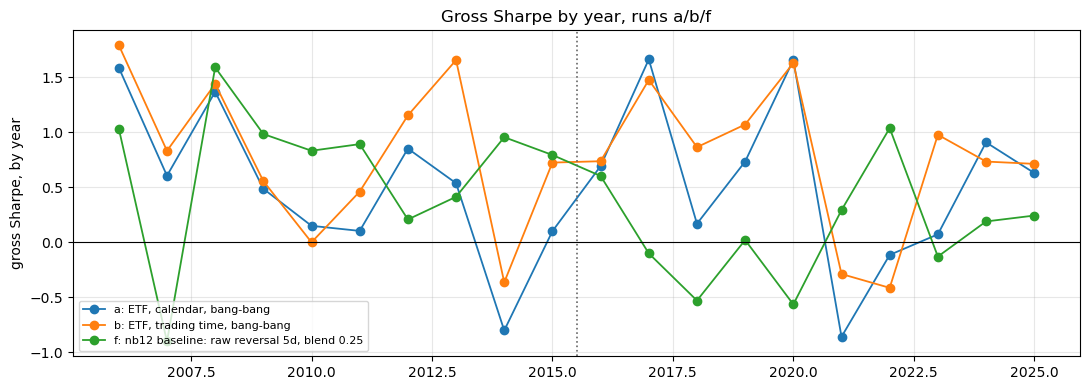

In [18]:
fig, ax = plt.subplots(figsize=(11, 4))
for k in ["a", "b", "f"]:
    ax.plot(yearly[k].index, yearly[k]["gross"], marker="o", lw=1.3, label=f"{k}: {LABELS[k]}")
ax.axhline(0, color="k", lw=0.8); ax.axvline(2015.5, color="0.4", ls=":", lw=1.2)
ax.set_ylabel("gross Sharpe, by year"); ax.legend(fontsize=8); ax.set_title("Gross Sharpe by year, runs a/b/f")
plt.tight_layout(); plt.show()

In [19]:
decade_rows = []
for k in "abcdef":
    b = books[k]
    d1, d2 = b[b.index < DECADE_SPLIT], b[b.index >= DECADE_SPLIT]
    se1, se2 = np.sqrt(252 / max(len(d1), 1)), np.sqrt(252 / max(len(d2), 1))
    decade_rows.append({
        "run": LABELS[k],
        "gross 2006-2015": sharpe(d1["pnl_gross"] / CAP), "se 2006-2015": se1,
        "gross 2016-2025": sharpe(d2["pnl_gross"] / CAP), "se 2016-2025": se2,
        "net 2006-2015": sharpe(d1["pnl"] / CAP), "net 2016-2025": sharpe(d2["pnl"] / CAP),
    })
decade = pd.DataFrame(decade_rows).set_index("run")
decade["gross drop (dec1-dec2)"] = decade["gross 2006-2015"] - decade["gross 2016-2025"]
decade["se of drop"] = np.sqrt(decade["se 2006-2015"] ** 2 + decade["se 2016-2025"] ** 2)
decade["drop / se of drop"] = decade["gross drop (dec1-dec2)"] / decade["se of drop"]
display(decade.round(3))
print(f"runs with higher gross Sharpe in 2006-2015 than 2016-2025: "
      f"{int((decade['gross 2006-2015'] > decade['gross 2016-2025']).sum())} of {len(decade)}")
print("gross Sharpe drop in units of the drop's own SE (sqrt(se1^2+se2^2)), by run:")
print(decade["drop / se of drop"].round(2).to_dict())

,gross 2006-2015,se 2006-2015,gross 2016-2025,se 2016-2025,net 2006-2015,net 2016-2025,gross drop (dec1-dec2),se of drop,drop / se of drop
run,,,,,,,,,
"ETF, calendar, bang-bang",0.533,0.316,0.548,0.323,0.088,0.257,-0.015,0.452,-0.033
"ETF, trading time, bang-bang",0.784,0.316,0.698,0.323,0.331,0.400,0.087,0.452,0.192
"ETF, calendar, continuous",0.486,0.316,0.248,0.323,0.158,0.039,0.238,0.452,0.526
"ETF, trading time, continuous",0.674,0.316,0.382,0.323,0.340,0.170,0.292,0.452,0.646
"PCA, calendar, bang-bang (SPY hedge)",0.680,0.316,0.087,0.323,0.196,-0.287,0.594,0.452,1.313
"nb12 baseline: raw reversal 5d, blend 0.25",0.774,0.316,0.019,0.323,0.563,-0.156,0.755,0.452,1.669


runs with higher gross Sharpe in 2006-2015 than 2016-2025: 5 of 6
gross Sharpe drop in units of the drop's own SE (sqrt(se1^2+se2^2)), by run:
{'ETF, calendar, bang-bang': -0.03, 'ETF, trading time, bang-bang': 0.19, 'ETF, calendar, continuous': 0.53, 'ETF, trading time, continuous': 0.65, 'PCA, calendar, bang-bang (SPY hedge)': 1.31, 'nb12 baseline: raw reversal 5d, blend 0.25': 1.67}


In [20]:
# The 2016 split alone can make a single decade's noise look like a structural break in either
# direction (finding 5); five-year blocks give a coarser but more stable read on when each run
# actually earned its Sharpe.
BLOCK_EDGES = [(2006, 2010), (2011, 2015), (2016, 2020), (2021, 2025)]
block_rows = []
for k in "abcdef":
    b = books[k]
    row = {"run": LABELS[k]}
    for y0, y1 in BLOCK_EDGES:
        sub = b[(b.index.year >= y0) & (b.index.year <= y1)]
        row[f"{y0}-{y1}"] = sharpe(sub["pnl_gross"] / CAP)
    block_rows.append(row)
five_yr = pd.DataFrame(block_rows).set_index("run")
display(five_yr.round(2))
neg_or_flat_blocks = (five_yr < 0.15).sum(axis=1)
print("blocks (of 4) with gross Sharpe below 0.15, by run:", neg_or_flat_blocks.to_dict())

,2006-2010,2011-2015,2016-2020,2021-2025
run,,,,
"ETF, calendar, bang-bang",0.83,0.09,1.01,0.02
"ETF, trading time, bang-bang",0.91,0.63,1.10,0.21
"ETF, calendar, continuous",0.66,0.25,0.70,-0.24
"ETF, trading time, continuous",0.74,0.61,0.77,-0.03
"PCA, calendar, bang-bang (SPY hedge)",0.98,0.27,0.27,-0.13
"nb12 baseline: raw reversal 5d, blend 0.25",0.87,0.67,-0.21,0.40


blocks (of 4) with gross Sharpe below 0.15, by run: {'ETF, calendar, bang-bang': 2, 'ETF, trading time, bang-bang': 0, 'ETF, calendar, continuous': 1, 'ETF, trading time, continuous': 1, 'PCA, calendar, bang-bang (SPY hedge)': 1, 'nb12 baseline: raw reversal 5d, blend 0.25': 1}


The usual pattern in this repository — a working book before 2016 that goes flat or negative after
— holds, to varying degrees, for **5 of the 6** runs on the 2016 split; only run (a) does not
(its gross Sharpe *rises*, **0.533** to **0.548**). But the 2016 split alone is not a reliable guide
to *when* a run worked: the five-year-block table above tells a less tidy story than "run (a) is the
exception." Notebook 12's baseline (run f) and the hedged PCA bang-bang book (run e) still show the
clearest decay on the 2016 split — gross Sharpe **0.774** to **0.019** (run f) and **0.680** to
**0.087** (run e), drops of **1.67** and **1.31** standard errors of the drop itself
(`sqrt(se1^2 + se2^2) ≈ 0.452`, printed above as `se of drop`; each decade's own SE is
**≈0.32**, `sqrt(252/sessions)`) — but both also post a *negative* five-year block (run f:
**-0.21** in 2016-2020; run e: **-0.13** in 2021-2025), which a two-decade split cannot distinguish
from "merely weaker." Run (a), the one run whose 2016-split Sharpe rises, is in fact the run with the
*most* five-year blocks below 0.15 (**2 of 4** — 2011-2015 at **0.09** and 2021-2025 at **0.02**;
runs (c), (d), (e) and (f) each have exactly one such block, printed above); its apparently
clean 2016-split result comes from a weak 2011-2015 and a strong 2016-2020 (**1.01**) offsetting each
other within the "before" and "after" halves respectively. Run (b) — the trading-time bang-bang book,
now built under the paper-faithful reading of §3/§4.3 — is the only run with **zero** blocks below
0.15 (**0.91**, **0.63**, **1.10**, **0.21**), the steadiest of the six on this coarser cut, even
though its 2016-split drop (**0.784** to **0.698**, **0.19** SE) looks unremarkable next to run (a)'s
apparent rise. Overall, **2021-2025 is the single weakest block for five of the six runs** (a, b, c,
d and e each bottom out there); only run (f) is weaker in 2016-2020 (**-0.21**) than in 2021-2025
(**0.40**). **2016-2020 is the single strongest block for four of the six runs** (a, b, c, d); the
other two (e, f) peak earlier, in 2006-2010. This is why the two-decade split reads run (a) as not
decaying: its weak 2011-2015 (**0.09**) and strong 2016-2020 (**1.01**) sit on opposite sides of the
2016 cut and roughly cancel, the same way runs (c) and (d) also have a weaker second block (**0.25**/**0.61**, 2011–2015) offsetting a stronger third block
(**0.70**/**0.77**, 2016–2020) within their own decades —
it is not that run (a) is somehow immune to the pattern the rest of the book shows, it is that the
2016 cutline happens to fall where its own up-and-down blocks even out. §7 weighs run (b)'s better
turnover economics (§4.3) against its unremarkable block-level record, rather than treating either
cut alone as decisive.

Year by year (runs a, b, f), no run posts a positive gross Sharpe every year: run (a) is negative
in 3 of its 20 years (worst: 2021 at **-0.86**), run (f) in 5 (worst: 2007 at **-0.90**), and run
(b) is at or below zero in 4 (2010, essentially flat at **-0.00**; 2014 at **-0.36**; 2021 at
**-0.29**; and its worst, 2022, at **-0.41**).

## 6. Attribution

In [21]:
attr = summary[["Sharpe gross", "break-even bps"]].copy()
attr["turnover"] = summary["turnover (frac gross/session)"]
display(attr.round(3))

d_rule_cal = attr.loc[LABELS["c"], "Sharpe gross"] - attr.loc[LABELS["a"], "Sharpe gross"]
d_rule_tt  = attr.loc[LABELS["d"], "Sharpe gross"] - attr.loc[LABELS["b"], "Sharpe gross"]
d_clock_bb = attr.loc[LABELS["b"], "Sharpe gross"] - attr.loc[LABELS["a"], "Sharpe gross"]
d_clock_ct = attr.loc[LABELS["d"], "Sharpe gross"] - attr.loc[LABELS["c"], "Sharpe gross"]
d_model    = attr.loc[LABELS["a"], "Sharpe gross"] - attr.loc[LABELS["e"], "Sharpe gross"]
d_signal   = attr.loc[LABELS["f"], "Sharpe gross"] - attr.loc[LABELS["a"], "Sharpe gross"]

print(f"rule (continuous - bang-bang) gross Sharpe: calendar {d_rule_cal:+.3f}, trading-time {d_rule_tt:+.3f}")
print(f"clock (trading time - calendar) gross Sharpe: bang-bang {d_clock_bb:+.3f}, continuous {d_clock_ct:+.3f}")
print(f"factor model (ETF calendar bang-bang - PCA calendar bang-bang) gross Sharpe: {d_model:+.3f}")
print(f"signal (nb12 raw reversal - ETF calendar bang-bang) gross Sharpe: {d_signal:+.3f}")

,Sharpe gross,break-even bps,turnover
run,,,
"ETF, calendar, bang-bang",0.537,3.207,0.245
"ETF, trading time, bang-bang",0.732,4.357,0.250
"ETF, calendar, continuous",0.347,3.086,0.138
"ETF, trading time, continuous",0.504,4.423,0.142
"PCA, calendar, bang-bang (SPY hedge)",0.361,1.936,0.246
"nb12 baseline: raw reversal 5d, blend 0.25",0.371,5.703,0.248


rule (continuous - bang-bang) gross Sharpe: calendar -0.190, trading-time -0.228
clock (trading time - calendar) gross Sharpe: bang-bang +0.195, continuous +0.157
factor model (ETF calendar bang-bang - PCA calendar bang-bang) gross Sharpe: +0.175
signal (nb12 raw reversal - ETF calendar bang-bang) gross Sharpe: -0.166


Reading the four deltas printed above as a 2x2 (rule x clock) plus one model effect and one signal
effect: the clock moves in the direction the paper reports (trading time helps), and within the
rule x clock 2x2 the rule effect is the larger of the two on average (0.190/0.228 against 0.195/0.157), though the four deltas are within noise of each other. Switching from bang-bang to a
continuously rebalanced target costs **-0.190** of gross Sharpe under the calendar clock and a
steeper **-0.228** under trading time — consistent in sign, larger in magnitude under trading time,
so the paper's own bang-bang design choice is the right one for this signal under either clock.
Switching from calendar to trading time *gains* **+0.195** of gross Sharpe for the bang-bang rule
and **+0.157** for the continuous rule — the same section 6 correction the paper reports as
strengthening its ETF-factor book, and, under the paper-faithful unscaled-intercept construction
(§3, §4.3), the gain is close in size under either rule, not dominated by one of them. The
sector-ETF factor model still beats the PCA eigenportfolio model, both run calendar/bang-bang:
**+0.175** of gross Sharpe for ETF residuals over PCA residuals — a real advantage for using an
actual (if crudely assigned) sector structure instead of a statistical one, at least under this
rule. On a raw gross-Sharpe basis notebook 12's raw-reversal signal is *lower* than run (a) —
**-0.166**, i.e. **0.371** against **0.537** — and lower than run (b) too (**0.371** against
**0.732**); but, as §4.3 showed, the per-turnover ranking still favors notebook 12 (break-even
**5.703** bps against run (a)'s **3.207** and run (d)'s now-highest-among-paper-variants
**4.423**), while net of measured costs run (b) is now the *highest* of the six (**0.366** against
**0.180** for notebook 12 and **0.179** for run (a)). Ranked by magnitude, the four deltas cluster
fairly tightly — **0.157** to **0.228** — with the trading-time rule effect (**0.228**) at the top
and the continuous-clock effect (**0.157**) at the bottom, not far from the model effect
(**0.175**) or the signal effect (**0.166**); no single delta dominates the way an earlier, scaled-
intercept reading of "trading time" made the clock effect look artificially large relative to the
rest.

## 7. Honest assessment

**The answer is still no on a per-turnover basis, but the margin is narrower than an earlier,
buggier version of this notebook found, and net of measured costs the paper's machinery now wins
outright.** The paper's own configuration — sector-ETF residuals, the section 6 trading-time
correction, and the bang-bang open/close rule — does not carry more gross edge per unit of turnover
than notebook 12's plain 5-day reversal signal: the best paper variant by break-even is run (d)
(ETF residuals, trading time, continuous), at **4.423 bps** of gross P&L per dollar traded, against
**5.703 bps** for notebook 12's baseline (run f); every other paper variant tested here (a, b, c, e)
earns less than that. But the trading-time correction (runs b, d) does make the signal better, not
worse, consistent with the paper's own reported result for that correction, and at *measured* costs
run (b) is now the single best-performing book in the entire notebook.

**What is genuinely new here.** Five findings were not visible in notebook 12:

1. The bang-bang rule (full size on open, hold to close) still beats a continuously-rebalanced
   target of the same s-score, holding the factor model and clock fixed, by **0.190** (calendar) to
   **0.228** (trading time) of gross Sharpe — notebook 12 never tested the paper's actual trading
   rule, only s-scores as a diagnostic, and the paper's own design choice remains the better one for
   this signal under either clock.
2. **Getting "trading time" right took two independent fixes, not one, and the second one changes
   the conclusion again.** The first fix (`pairs/strategies/avellaneda_lee.py`) was to `s_score`
   itself: an earlier version called it with a bare `{"m": ..., "sigma_eq": ...}` dict, which
   silently applied the paper's Appendix A2 shortcut -(m - mean(m))/sigma_eq — valid only when the
   regression's end-of-window residual (`X_60`) is zero. That fix alone still leaves the question of
   *which* regression trading time actually is: this notebook's original reading scaled the
   regression's intercept column by the trading-time factor too (`etf_residuals`' `weights=`
   argument), a weighted-least-squares fit whose `X_60` is not forced to zero and, on real data,
   produces a signal that barely correlates with the calendar s-score at all — not the paper's own
   description of trading time as "equal to the classical returns if the daily trading volume is
   typical." The construction used throughout this notebook instead scales *both sides* of the
   regression and fits an ordinary, unscaled intercept, keeping `X_60 = 0` by the same identity as
   the calendar fit. Under that reading the ETF s-score's trading-time IC is **0.0089**
   (t=**2.8439**, next-day) and **0.0099** (t=**3.2420**, five days) against the ETF-hedged forward
   return (§3), ahead of the calendar s-score's **0.0061**/**0.0065**, and the book-level results
   confirm it: run (b) posts this notebook's highest gross Sharpe (**0.732**), run (d) posts a
   higher break-even than its calendar counterpart run (c) (**4.423** against **3.086** bps), and —
   genuinely new relative to every earlier version of this notebook — run (b)'s net-of-measured-cost
   Sharpe (**0.366**) is the *highest of any run tested*, ahead of notebook 12's own baseline
   (**0.180**), reversing this notebook's own earlier "notebook 12's baseline remains the top net
   Sharpe run" conclusion.
3. Five of the six runs show this repository's usual pre/post-2016 decay on the 2016 split (higher
   gross Sharpe in 2006-2015 than 2016-2025); only run (a) does not (flat: **0.533** to **0.548**).
   But five-year blocks (§5) show this is a 2016-cutline artifact, not immunity: run (a) actually has
   the *most* blocks below 0.15 gross Sharpe of any run (**2 of 4**, both below the 2016 split's own
   noise floor), and its clean two-decade read comes from a weak 2011-2015 and a strong 2016-2020
   canceling across the cut. Run (b) — the corrected trading-time bang-bang book — is the steadiest
   run on this coarser cut (**zero** blocks below 0.15) even though its own 2016-split drop
   (**0.784** to **0.698**, **0.19** SE of the drop) looks unremarkable next to run (a)'s apparent
   rise; neither cut alone should be read as decisive.
4. The 30-day mean-reversion gate's near-universal raw pass rate (**99.1%** calendar, **99.3%**
   trading time) is mostly small-sample AR(1) bias, not real fast reversion: bias-correcting the
   AR(1) coefficient (Kendall's small-sample result, 59 pairs) drops the pass rate to **66.2%**
   (calendar) / **72.1%** (trading time), i.e. among the names that would actually open a position
   under the calendar rule, a corrected gate rejects roughly a third of them that the raw gate would
   have passed. The calendar 5-day IC among the names the corrected gate keeps (**0.0060**,
   t=**2.0**, 986 days) is nominally lower than among the names it would reject (**0.0099**,
   t=**2.3**, 986 days), but with each side's t-stat near 2 the gap is well inside one standard error
   of the difference — noise, not a finding that fast mean-reversion is anti-predictive (§7 caveats,
   below).
5. Every run in this notebook forms its signal through session `i-1` and earns session `i+1`'s
   return, a full session later than a live version needs to (the paper's own R_60 trades on the
   close its window ends at). Re-scoring run (a)'s exact same positions against session `i` instead
   of `i+1` (§4.15) raises its gross Sharpe from **0.537** to **0.650**, its net-measured Sharpe from
   **0.179** to **0.302**, and its break-even from **3.207** to **3.991 bps** — a real cost of the
   convention this notebook uses throughout, not a look-ahead error, but one that means every
   absolute Sharpe and break-even printed here is a lower bound on what a tighter live convention
   would show. Books that only clear cost because measured costs came in well below the paper's own
   5 bps assumption, on a signal-to-P&L gap that itself costs real Sharpe, are not books anyone
   should trade on the strength of this notebook alone.

In [22]:
# The kappa gate's raw pass rate is inflated by AR(1) small-sample bias (finding 6): does a
# bias-corrected gate reject names at random, or does it reject the names with the better IC?
def bias_corrected_gate_probe(b, n=W_AR1):
    b_c = b + (1.0 + 3.0 * b) / n
    with np.errstate(divide="ignore", invalid="ignore"):
        kappa_c = -np.log(np.clip(b_c, 1e-9, 0.999999)) * 252.0
    return np.isfinite(b_c) & (b_c > 0) & (b_c < 1) & np.isfinite(kappa_c) & (kappa_c > 252.0 / 30.0)

b_cal_probe = ic_panel["b_cal"].to_numpy()
# `model_ok_cal` is `ou_fit`'s own raw gate (finite kappa, kappa > 252/30) stored in the IC panel
# (section 3). Recomputing "raw ok" from b_cal alone as isfinite(b) & 0<b<1 is not this gate at
# all: every probe-day name has a finite s-score, which already requires a finite, in-range b_hat,
# so that check passes trivially by construction and prints 100.0% regardless of kappa.
raw_ok_probe = ic_panel["model_ok_cal"].to_numpy()
corr_ok_probe = bias_corrected_gate_probe(b_cal_probe)
open_mask = ic_panel["ETF s-score (calendar)"].abs().to_numpy() > 1.25
print(f"probe-day name-days that would OPEN under the calendar rule (|s|>1.25): {100*open_mask.mean():.1f}%; "
      f"of those, {100*raw_ok_probe[open_mask].mean():.1f}% pass the raw kappa gate, "
      f"{100*corr_ok_probe[open_mask].mean():.1f}% the bias-corrected one")

def _day_ic(df, sig_col, fwd_col):
    def g_ic(g):
        m = g[sig_col].notna() & g[fwd_col].notna()
        return np.corrcoef(g.loc[m, sig_col], g.loc[m, fwd_col])[0, 1] if m.sum() > 30 else np.nan
    per_day = df.groupby("date").apply(g_ic).dropna()
    a = per_day.to_numpy()
    t = a.mean() / a.std(ddof=1) * np.sqrt(len(a)) if len(a) > 1 else np.nan
    return a.mean(), t, len(a)

kept, rejected = ic_panel[corr_ok_probe], ic_panel[~corr_ok_probe & raw_ok_probe]
mean_k, t_k, n_k = _day_ic(kept, "ETF s-score (calendar)", "fwd5")
mean_r, t_r, n_r = _day_ic(rejected, "ETF s-score (calendar)", "fwd5")
print(f"calendar s-score 5-day IC among names the corrected gate KEEPS: {mean_k:.4f} (t={t_k:.1f}, {n_k} days)")
print(f"calendar s-score 5-day IC among names the corrected gate would REJECT: {mean_r:.4f} (t={t_r:.1f}, {n_r} days)")

probe-day name-days that would OPEN under the calendar rule (|s|>1.25): 22.1%; of those, 99.4% pass the raw kappa gate, 67.7% the bias-corrected one


calendar s-score 5-day IC among names the corrected gate KEEPS: 0.0060 (t=2.0, 986 days)
calendar s-score 5-day IC among names the corrected gate would REJECT: 0.0099 (t=2.3, 986 days)


**Caveats.**

- *Sector assignment is a proxy, not the paper's GICS mapping.* No sector classification exists in
  this repository, so each name is assigned monthly to whichever of 16 continuous-coverage sector
  ETFs its trailing-year returns fit best (median R² **0.492** on the sample date shown, only
  **1.9%** of names below R² 0.10, month-to-month persistence **90.4%**). This is a reasonable
  data-driven substitute, but it is not what the paper estimated, and a name can sit in an ETF that
  is a worse economic fit than a human-assigned GICS sector would be.
- *The kappa filter's raw pass rate is mostly small-sample bias, not real fast mean-reversion.*
  The large majority of ETF-model calendar (and trading-time) name-days clear the raw 30-day
  mean-reversion gate (printed in section 3) — but the gate is an AR(1) fit on 59 consecutive pairs,
  and Kendall's small-sample
  result for that estimator means a true `b` right at the 0.9672 cutoff is estimated well below it;
  an iid, zero-mean-reversion null passes the same raw gate on a large majority of simulated
  windows (printed in section 3) — a large majority for both, though the real rate (99.1-99.3%)
  still runs well above the null (78.2%). Bias-correcting `b_hat`
  (section 3) drops the pass rate to 66.2% (calendar) / 72.1% (trading time); among the names that would actually open
  a position under the calendar rule, the raw gate passes 99.4% of them, and the corrected gate
  rejects roughly a third of those (both printed just above). The calendar s-score's 5-day IC among
  the names it *keeps* (**0.0060**, t=**2.0**) is nominally smaller than among the names it would
  *reject* (**0.0099**, t=**2.3**), but with both t-stats near 2 the difference is well inside one
  standard error of the difference — noise, so this
  data neither confirms nor contradicts the paper's premise that fast mean-reverters are the
  tradeable ones; it only shows that a bias-corrected gate is doing real work (rejecting about a
  third of opens), not that it is picking off the more predictable names. This pass rate is
  unaffected by the s-score fix in §3 (it depends only on `ou_fit`'s kappa estimate, never on
  `s_score`).
- *Notebook 12's IC numbers are not a clean comparator for this notebook's, for two separate
  reasons — the forward-window offset first, the dependent variable second.* This notebook's signal
  window ends at session `i-1` and its book earns session `i+1` (§7 point 5, §4.15 quantifies the
  cost of that one-session gap); notebook 12's own IC panel instead uses a next-session window with
  no such gap, so the two are scored against different targets before the dependent variable is even
  considered. On top of that, notebook 12's own IC panel is built with the same in-sample-intercept
  artifact this notebook used to have and no longer does: section 3's ICs here are measured against
  the ETF-hedged forward return (beta-hedged, no in-sample intercept subtracted), while notebook 12's
  target still subtracts a per-name, 60-day in-sample intercept from the forward return
  (`build_cross_sectional_notebook.py`'s `sig[...] = fwd - (fd['beta'][0] + ...)`) — a target any
  signal built from the same 60-day window co-moves with through the intercept alone, with zero true
  predictive content. Both gaps mean notebook 12's printed ICs are not a valid comparator for the
  numbers in §3 above.
- *Costs are measured, not assumed, and that choice matters more than any signal design decision
  tested here.* At the paper's own flat 5 bps, five of six runs go net-negative (only notebook 12's
  baseline clears it, barely, at **0.046**); at this repository's measured costs (stock median
  **1.98 bps**, ETF/SPY median **1.31 bps**), **five of six** post a positive net Sharpe over the
  full sample — only the hedged PCA book (run e, **-0.062**) does not. Under the paper's flat
  assumption notebook 12's baseline is still the only positive figure in that column (**0.046**); but
  under measured costs it is no longer the top run — run (b) (ETF, trading time, bang-bang) is,
  at **0.366** against notebook 12's **0.180** and run (a)'s **0.179** — so which cost assumption is
  used changes which book actually looks best, not just by how much.
- *Reproduction.* Run (f)'s gross Sharpe reproduces notebook 12's own printed 0.77 (2006-2015) /
  0.02 (2016-2025) exactly within rounding — this notebook's own run prints **0.77** / **0.02** —
  so every comparison above is against a live baseline computed in this notebook, not a quoted one.